<a href="https://colab.research.google.com/github/muhammetozcan07/Akilli_sehir_aydinlatma/blob/main/akilli_sehir_aydinlatma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- ADIM 10 ---
Sensörler verisi : Akşam, ⛅ Hafif Aydınlık, 🚶 Biri geçiyor
Yapay Zeka Kararı  : Lambayı MID [%50 Güç] yap
Alınan Puan        : 2
-------------------

Test tamamlandı.


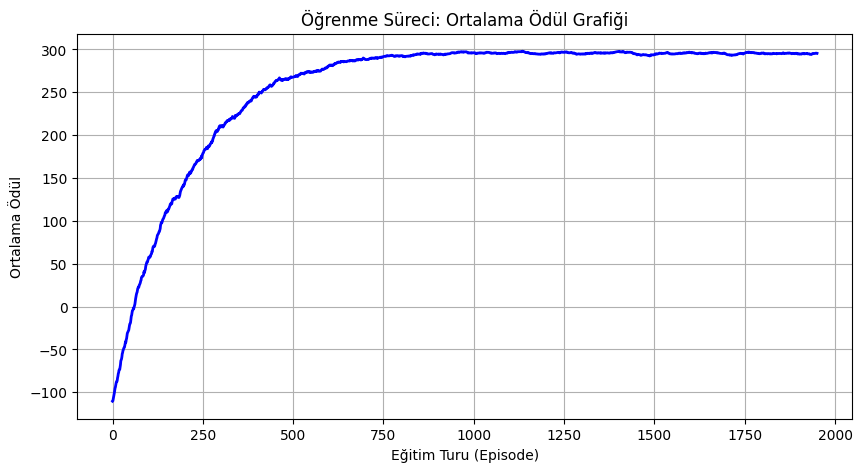

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time
from IPython.display import clear_output

class SmartLightingEnv:
    def __init__(self):

        # State (Durum) Uzayları: Ortamın içinde bulunabileceği tüm olası durumlar.
        self.motions = [0, 1]          # Ortamda hareket var mı? 0: Yok, 1: Var
        self.lights = [0, 1, 2]        # Doğal ışık seviyesi. 0: Karanlık, 1: Alacakaranlık, 2: Aydınlık
        self.times = [0, 1, 2, 3]      # Günün saati. 0: Gece, 1: Sabah, 2: Öğle, 3: Akşam

        # Action (Aksiyon) Uzayı: Yapay zekanın yapabileceği eylemler.
        self.actions = [0, 1, 2]       # Lamba durumu. 0: Kapalı, 1: %50 Parlaklık, 2: %100 Parlaklık
        self.state = self.reset()      # Çevreyi ilk durumuyla başlatıyoruz.

    def reset(self):
        # Her eğitim turunun (episode) başında ortamı rastgele bir başlangıç durumuna sıfırlar.
        start_time = random.choice(self.times) # Rastgele bir zaman dilimi seçme.

        # Seçilen zamana göre mantıklı bir başlangıç ışığı belirleme.
        if start_time == 0: start_light = 0         # Eğer gece ise doğal ışık Karanlık (0) olur.
        elif start_time in [1, 3]: start_light = 1  # Sabah veya Akşam ise Alacakaranlık (1) olur.
        else: start_light = 2                       # Öğle ise Aydınlık (2) olur.

        # Başlangıç durumu: (Rastgele hareket, belirlenen ışık, seçilen zaman)
        self.state = (random.choice(self.motions), start_light, start_time)
        return self.state

    def step(self, action):
        # Yapay zeka bir eylem (action) seçtiğinde bu fonksiyon çalışır. Sonuçları ve ödülü döndürür.
        motion, light, time_of_day = self.state # Mevcut durumu değişkenlere ayırıyoruz.

        # ENERJİ CEZASI HESAPLAMASI: Fazla enerji harcamak yapay zekaya eksi puan (ceza) getirir.
        if action == 0: energy_penalty = 0      # Işık kapalıysa enerji harcanmaz, ceza yok.
        elif action == 1: energy_penalty = -1   # %50 açıksa az ceza.
        else: energy_penalty = -2               # %100 açıksa çok ceza.

        # GÜVENLİK/KONFOR PRİMİ HESAPLAMASI: Doğru zamanda doğru ışığı açmak ödül getirir.
        safety_bonus = 0
        if motion == 1: # Eğer ortamda BİRİ VARSA:
            if light == 0: # Ve ortam karanlıksa:
                if action == 0: safety_bonus = -10 # Lamba açılmazsa büyük ceza.
                elif action == 1: safety_bonus = 2 # %50 açılırsa biraz ödül.
                elif action == 2: safety_bonus = 5 # %100 açılırsa tam ödül.
            elif light == 1: # Ortam alacakaranlıksa:
                if action == 0: safety_bonus = -5  # Lamba kapalı kalırsa orta halli ceza.
                elif action == 1: safety_bonus = 3 # %50 açmak en ideal tercih.
                elif action == 2: safety_bonus = 1 # %100 açmak fena değil ama biraz gereksiz.
            elif light == 2: # Ortam zaten aydınlıksa (öğlen güneşi vb.):
                if action == 0: safety_bonus = 2   # Işığı kapalı tutmak ödül.
                elif action == 1: safety_bonus = -1# Boşuna açılırsa küçük ceza.
                elif action == 2: safety_bonus = -3# Tamamen açılırsa daha büyük ceza.
        else: # Eğer ortamda KİMSE YOKSA:
            if action == 0: safety_bonus = 3       # Kapalı tutmak en iyisi (ödül).
            elif action == 1: safety_bonus = -2    # Kimse yokken %50 açmak israf (ceza).
            elif action == 2: safety_bonus = -5    # Kimse yokken %100 açmak büyük israf (ceza).

        # Ekstra Durumlar (Gece güvenlik artırımı)
        if time_of_day == 0: # Eğer Gece ise
            if motion == 1 and action == 2: safety_bonus += 3 # Hareket varsa lambayı fullemek ekstra güvenli (ek ödül).
            elif motion == 0 and action == 0: safety_bonus += 2 # Hareket yoksa ve kapalıysa ekstra tasarruf ödülü.

        # Toplam ödül = Enerji faturası (ceza) + İnsanın güvenliği/konforu (ödül)
        reward = energy_penalty + safety_bonus

        # BİR SONRAKİ ZAMANA GEÇİŞ
        next_time = (time_of_day + 1) % len(self.times) # Saati bir ileri sarıyoruz (Gece->Sabah->Öğle->Akşam->Gece...)

        # Bir sonraki zamanda hareket olma olasılıkları (gerçek hayata uygun simülasyon)
        motion_probabilities = {0: 0.10, 1: 0.80, 2: 0.40, 3: 0.90} # 0: Gece (%10), 1: Sabah (%80), 2: Öğle (%40), 3: Akşam (%90) hareket olasılıkları.
        prob = motion_probabilities[next_time]

        # Olasılığa göre bir sonraki adımda biri geçecek mi hesaplama
        next_motion = 1 if random.random() < prob else 0

        # Zamana göre bir sonraki adımın doğal ışık miktarını ayarlama
        if next_time == 0: next_light = 0
        elif next_time in [1, 3]: next_light = 1
        else: next_light = 2

        # Ortamın yeni durumunu güncelleme ve kaydetme
        next_state = (next_motion, next_light, next_time)
        self.state = next_state

        return next_state, reward # Yeni durumu ve bu eylemden kazanılan ödülü geri döndürür.

# --- EĞİTİM KISMI ---

env = SmartLightingEnv() # Ortamı yaratıyoruz.

# Q-Table oluşturuluyor.
# Boyutu: 2 (hareket) x 3 (ışık) x 4 (zaman) x 3 (aksiyon) = 72 farklı hücre var.
q_table = np.zeros((len(env.motions), len(env.lights), len(env.times), len(env.actions)))

# Q-Learning Hiperparametreleri
alpha = 0.1           # Öğrenme katsayısı.
gamma = 0.9           # İndirim faktörü.
epsilon = 1.0         # Keşif oranı.
epsilon_decay = 0.995 # Her turda epsilon değerini çarparak küçültür.
min_epsilon = 0.01    # Rastgeleliğin inebileceği en düşük seviye.
episodes = 2000       # Yapay zekanın kaç gün/tur boyunca eğitileceği.

rewards_per_episode = [] # Gelişimi grafiğe dökmek için her turdaki puanları tutacağımız liste.

print("Yapay zeka eğitime başlıyor...")
for episode in range(episodes):
    state = env.reset() # Her yeni turda sistemi sıfırlıyoruz.
    total_reward = 0    # Bu turun toplam ödülünü sıfırlıyoruz.

    for step in range(100): # Her bir tur 100 adımdan oluşuyor
        # Epsilon-Greedy Algoritması: Ajan rastgele mi deneyecek yoksa bildiği en iyi şeyi mi yapacak?
        if random.uniform(0, 1) < epsilon:
            action = random.choice(env.actions)
        else:
            action = np.argmax(q_table[state[0], state[1], state[2]])

        # Eylemi sisteme uyguluyoruz, yeni durumu ve ödülü görüyoruz.
        next_state, reward = env.step(action)

        # --- Q-TABLOSU GÜNCELLEMESİ (Bellman Denklemi Uygulaması) ---
        old_value = q_table[state[0], state[1], state[2], action]
        next_max = np.max(q_table[next_state[0], next_state[1], next_state[2]])

        # Yeni puan = Eski Puan + Öğrenme Hızı * (Alınan Ödül + Gelecek Ödülü - Eski Puan)
        new_value = old_value + alpha * (reward + gamma * next_max - old_value)

        # Güncellenmiş puanı beyne (Q-tablosuna) yazıyoruz.
        q_table[state[0], state[1], state[2], action] = new_value

        state = next_state # Sistemin güncel durumunu, "yeni duruma" geçiriyoruz.
        total_reward += reward # Alınan ödülü turun toplamına ekliyoruz.


    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    rewards_per_episode.append(total_reward)

print("Eğitim bitti!")

# --- ÖDÜL GRAFİĞİ ÇİZİM KISMI ---
plt.figure(figsize=(10,5))
window = 50
moving_avg = np.convolve(rewards_per_episode, np.ones(window)/window, mode='valid')
plt.plot(moving_avg, color='blue', linewidth=2)
plt.title('Öğrenme Süreci: Ortalama Ödül Grafiği')
plt.xlabel('Eğitim Turu (Episode)')
plt.ylabel('Ortalama Ödül')
plt.grid(True)

# --- SİMÜLASYON (TEST) KISMI ---
# Eğitim bittikten sonra ajanımızın neler öğrendiğini canlı olarak izliyoruz.
print("Sistemi canlı test ediyoruz... (10 Adım)")
time.sleep(2)

state = env.reset()
for step in range(10):
    clear_output(wait=True)

    action = np.argmax(q_table[state[0], state[1], state[2]])
    next_state, reward = env.step(action)

    motion_str = "🚶 Biri geçiyor" if state[0] == 1 else "💨 Kimsecikler yok"
    light_str = {0: "🌑 Zifiri Karanlık", 1: "⛅ Hafif Aydınlık", 2: "☀️ Bildiğin Gündüz"}[state[1]]
    time_str = {0: "Gece", 1: "Sabah", 2: "Öğle", 3: "Akşam"}[state[2]]

    action_art = {
        0: "OFF [Kapalı]",
        1: "MID [%50 Güç]",
        2: "MAX [%100 Güç]"
    }[action]

    print(f"--- ADIM {step + 1} ---")
    print(f"Sensörler verisi : {time_str}, {light_str}, {motion_str}")
    print(f"Yapay Zeka Kararı  : Lambayı {action_art} yap")
    print(f"Alınan Puan        : {reward}")
    print("-------------------\n")

    state = next_state
    time.sleep(2)

print("Test tamamlandı.")
plt.show(block=True) # Arka planda çizilen başarı grafiğini ekrana getiriyoruz.